# 1. Read and Explore
Load the dataset and display basic info (head(), info(), describe())

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data=pd.read_csv("customer_sales_data.csv")
data.head()

,CustomerID,Name,Age,Gender,Region,Product,Quantity,UnitPrice,PurchaseDate,TotalAmount
0,101,Customer1,27,Male,North,Headphones,3,29561,2023-01-01,88683
1,102,Customer2,54,Female,West,Phone,1,18903,2023-01-16,18903
2,103,Customer3,33,Female,East,Tablet,4,8626,2023-01-31,34504
3,104,Customer4,18,Male,South,Headphones,2,24181,2023-02-15,48362
4,105,Customer5,46,Female,South,Headphones,1,27841,2023-03-02,27841


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerID    20 non-null     int64 
 1   Name          20 non-null     object
 2   Age           20 non-null     int64 
 3   Gender        20 non-null     object
 4   Region        20 non-null     object
 5   Product       20 non-null     object
 6   Quantity      20 non-null     int64 
 7   UnitPrice     20 non-null     int64 
 8   PurchaseDate  20 non-null     object
 9   TotalAmount   20 non-null     int64 
dtypes: int64(5), object(5)
memory usage: 1.7+ KB


In [6]:
data.describe()

,CustomerID,Age,Quantity,UnitPrice,TotalAmount
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,110.50000,39.400000,2.350000,26738.600000,63836.000000
std,5.91608,13.124505,1.089423,10777.011325,43765.653137
min,101.00000,18.000000,1.000000,6362.000000,6362.000000
25%,105.75000,27.000000,1.000000,19629.000000,35735.500000
50%,110.50000,42.500000,2.500000,26035.000000,48653.500000
75%,115.25000,51.750000,3.000000,35398.000000,87936.000000
max,120.00000,58.000000,4.000000,45720.000000,170444.000000


# 2.
Filter Customers from ‘North’ Who Bought More Than 2 Items

In [7]:
data.loc[(data['Region']=='North') & (data['Quantity']>2)]

,CustomerID,Name,Age,Gender,Region,Product,Quantity,UnitPrice,PurchaseDate,TotalAmount
0,101,Customer1,27,Male,North,Headphones,3,29561,2023-01-01,88683
8,109,Customer9,26,Female,North,Tablet,3,29229,2023-05-01,87687
10,111,Customer11,18,Female,North,Laptop,3,22298,2023-05-31,66894
12,113,Customer13,54,Male,North,Phone,4,39307,2023-06-30,157228


# 3.
Add a New Column ‘DiscountedAmount’
Apply 10% discount if Quantity >= 3, else no discount.

In [19]:
import numpy as np
data['DiscountedAmount']=np.where(data['Quantity']>=3,0.9*data['TotalAmount'],data['TotalAmount'])

In [20]:
data

,CustomerID,Name,Age,Gender,Region,Product,Quantity,UnitPrice,PurchaseDate,TotalAmount,DiscountedAmount
0,101,Customer1,27,Male,North,Headphones,3,29561,2023-01-01,88683,79814.7
1,102,Customer2,54,Female,West,Phone,1,18903,2023-01-16,18903,18903.0
2,103,Customer3,33,Female,East,Tablet,4,8626,2023-01-31,34504,31053.6
3,104,Customer4,18,Male,South,Headphones,2,24181,2023-02-15,48362,48362.0
4,105,Customer5,46,Female,South,Headphones,1,27841,2023-03-02,27841,27841.0
5,106,Customer6,43,Female,East,Laptop,4,42611,2023-03-17,170444,153399.6
6,107,Customer7,47,Female,West,Phone,2,35632,2023-04-01,71264,71264.0
7,108,Customer8,47,Female,East,Laptop,3,33633,2023-04-16,100899,90809.1
8,109,Customer9,26,Female,North,Tablet,3,29229,2023-05-01,87687,78918.3
9,110,Customer10,27,Male,West,Laptop,2,19976,2023-05-16,39952,39952.0


# 4.
Find Total Revenue Generated per Product

In [21]:
data.groupby('Product')['TotalAmount'].sum()

Product
Headphones    210606
Laptop        554422
Phone         247395
Tablet        264297
Name: TotalAmount, dtype: int64

# 5.
Show Region-Wise Average Total Purchase

In [28]:
data.groupby('Region')['TotalAmount'].mean().round(2)

Region
East     84750.67
North    73833.33
South    33477.33
West     44956.80
Name: TotalAmount, dtype: float64

# 6
Create a Barplot of Product vs. Total Quantity Sold

<Axes: xlabel='Product', ylabel='Quantity'>

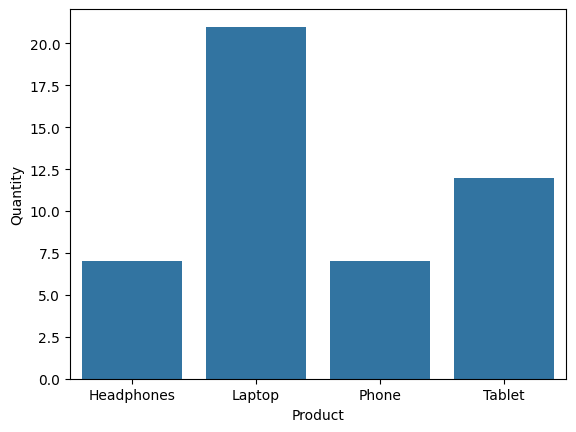

In [38]:
t=data.groupby('Product')['Quantity'].sum()
#sns.barplot(x='Product',y='Quantity',data=data,hue='Product')
sns.barplot(t)

# 7
Show Age Distribution with a Histogram

(array([2., 0., 5., 1., 1., 0., 2., 3., 1., 5.]),
 array([18., 22., 26., 30., 34., 38., 42., 46., 50., 54., 58.]),
 <BarContainer object of 10 artists>)

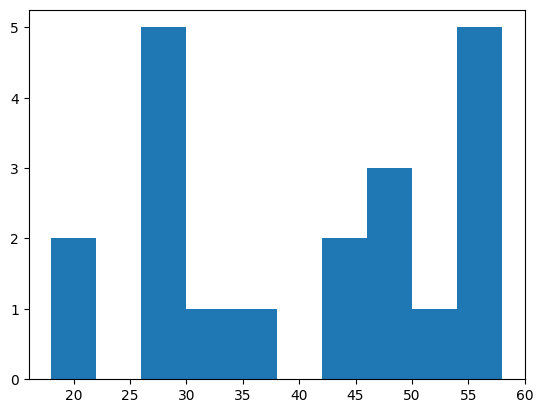

In [44]:
plt.hist(data['Age'])

<Axes: xlabel='Age', ylabel='Count'>

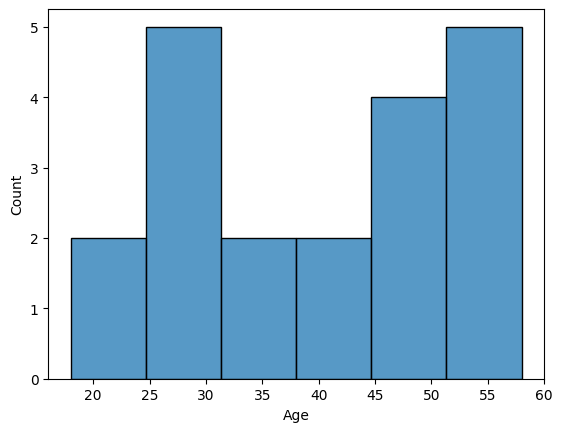

In [42]:
sns.histplot(data['Age'])

# 8
Create a Pivot Table: Region vs Product Total Sales

In [46]:
pivot_table = pd.pivot_table(data,values='TotalAmount',index='Region',columns='Product',aggfunc='sum',fill_value=0)

print(pivot_table)

Product  Headphones  Laptop   Phone  Tablet
Region                                     
East              0  368040       0  140464
North         88683   73256  157228  123833
South         76203   24229       0       0
West          45720   88897   90167       0


# 9
Extract Year and Month from PurchaseDate

In [52]:
data['PurchaseDate']=pd.to_datetime(data['PurchaseDate'])
data['Year']=data['PurchaseDate'].dt.year
data['Month']=data['PurchaseDate'].dt.month
data

,CustomerID,Name,Age,Gender,Region,Product,Quantity,UnitPrice,PurchaseDate,TotalAmount,DiscountedAmount,Year,Month
0,101,Customer1,27,Male,North,Headphones,3,29561,2023-01-01,88683,79814.7,2023,1
1,102,Customer2,54,Female,West,Phone,1,18903,2023-01-16,18903,18903.0,2023,1
2,103,Customer3,33,Female,East,Tablet,4,8626,2023-01-31,34504,31053.6,2023,1
3,104,Customer4,18,Male,South,Headphones,2,24181,2023-02-15,48362,48362.0,2023,2
4,105,Customer5,46,Female,South,Headphones,1,27841,2023-03-02,27841,27841.0,2023,3
5,106,Customer6,43,Female,East,Laptop,4,42611,2023-03-17,170444,153399.6,2023,3
6,107,Customer7,47,Female,West,Phone,2,35632,2023-04-01,71264,71264.0,2023,4
7,108,Customer8,47,Female,East,Laptop,3,33633,2023-04-16,100899,90809.1,2023,4
8,109,Customer9,26,Female,North,Tablet,3,29229,2023-05-01,87687,78918.3,2023,5
9,110,Customer10,27,Male,West,Laptop,2,19976,2023-05-16,39952,39952.0,2023,5


# 10
Save Cleaned & Transformed Dataset to New File

In [54]:
df=data.to_csv("sales.csv")